In [1]:
!hostname

gnode014.cluster


In [2]:
!nvidia-smi

Wed Feb 19 15:36:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 PCIe               Off |   00000000:A8:00.0 Off |                    0 |
| N/A   29C    P0             49W /  350W |       1MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
import itertools as it
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import torch.fft
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sdeint
from toolbox import (
    make_loss,
    StatLoss,
    SINN,
    FPU
)
from scipy.stats import gaussian_kde

In [4]:
torch.cuda.is_available()

True

In [5]:
device = torch.device('cuda')

In [6]:
print(torch.__version__)
print(torch.version.cuda)

2.0.1+cu118
11.8


In [7]:
seed = 6666
torch.set_default_dtype(torch.float)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

xhi=1000
yhi=1
ra1=0.5
rd1=1.0
ra2=2.0
rd2=3.0
Nrun=400
Nstep=20000
deltat=0.01

In [8]:
batch = 400                            # Batch size 
sec_length = 400                       # Length of the input sequence 

traj_theta1 = np.loadtxt('KMC_SINNtraj_spec1_Nsite100.txt')
traj_theta2 = np.loadtxt('KMC_SINNtraj_spec2_Nsite100.txt')
print(traj_theta1.shape,traj_theta2.shape)

(400, 400) (400, 400)


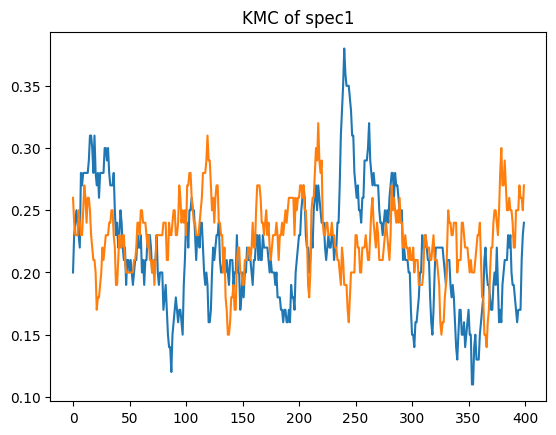

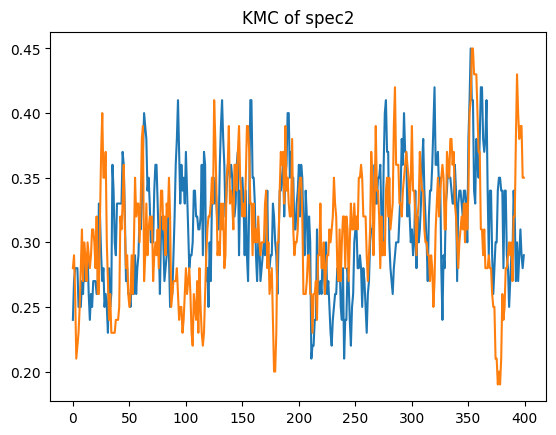

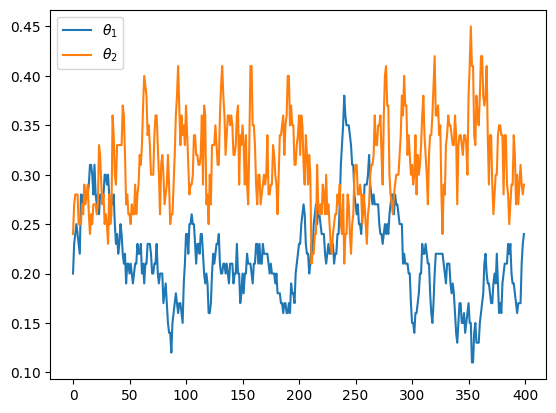

In [9]:
plt.figure(0)
for i in range(2):
    plt.plot(traj_theta1[:,i])
plt.title(r"KMC of spec1")


plt.figure(1)
for i in range(2):
    plt.plot(traj_theta2[:,i])
plt.title(r"KMC of spec2")

plt.figure(2)
plt.plot(traj_theta1[:,0], label=r'$\theta_1$')
plt.plot(traj_theta2[:,0], label=r'$\theta_2$')
plt.legend()

In [10]:
# Normalize data
mean1 = np.mean(traj_theta1)
std1 = np.std(traj_theta1)
mean2 = np.mean(traj_theta2)
std2 = np.std(traj_theta2)

In [11]:
Traj = np.empty((sec_length,batch,2))
Traj[:,:,0] = (traj_theta1-mean1)/std1
Traj[:,:,1] = (traj_theta2-mean2)/std2
print(Traj.shape)

(400, 400, 2)


In [12]:
# Reformulating data into Torch tensors 
# Input of SINN should be of the form (seq_len, batch, input_size)

ini = np.random.randn(2*sec_length,2*batch).astype(np.float32) 
input = torch.from_numpy(ini.reshape(2*sec_length, batch, 2)).to(device)
batch_validation = batch
val_set = torch.normal(0.0, 1.0, (2*sec_length, batch_validation, 2), device=device)


Traj = Traj.astype(np.float32) 
target = torch.from_numpy(Traj.reshape(sec_length, batch, 2)).to(device)
print('The torch input size is', input.size(), input.dtype)
print('The torch validation size is', val_set.size(), val_set.dtype)
print('The torch target size is', target.size(), target.dtype)

The torch input size is torch.Size([800, 400, 2]) torch.float32
The torch validation size is torch.Size([800, 400, 2]) torch.float32
The torch target size is torch.Size([400, 400, 2]) torch.float32


In [13]:
def scatter_hist(x, y, ax, ax_histx, ax_histy):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    # the scatter plot:
    ax.scatter(x, y, s=1)

    # now determine nice limits by hand:
    binwidth = 0.25
    xymax = max(np.max(x), np.max(y))
    xymin = min(np.min(x), np.min(y))
    
    # Ensure limits encompass the range of data
    lim_min = (int(xymin / binwidth) - 1) * binwidth  # Set minimum limit
    lim_max = (int(xymax / binwidth) + 1) * binwidth  # Set maximum limit

    # Create bins from lim_min to lim_max
    bins = np.arange(lim_min, lim_max + binwidth, binwidth)    
    
    ax_histx.hist(x, bins=bins, density=True, alpha=0.6)
    ax_histy.hist(y, bins=bins, density=True, alpha=0.6, orientation='horizontal')
    
    # Calculate KDE for x and y
    kde_x = gaussian_kde(x)
    kde_y = gaussian_kde(y)

    # Generate smooth values for the KDE curve
    x_vals = np.linspace(lim_min, lim_max, 400)
    y_vals = np.linspace(lim_min, lim_max, 400)

    # Plot KDE curves on the histograms
    ax_histx.plot(x_vals, kde_x(x_vals), color='red')
    ax_histy.plot(kde_y(y_vals), y_vals, color='red')
    
    # 2D KDE Calculation
    xy = np.vstack([x, y])
    kde_2d = gaussian_kde(xy)
    
    # Create a grid of x and y values
    xgrid, ygrid = np.meshgrid(np.linspace(lim_min, lim_max, 400), 
                               np.linspace(lim_min, lim_max, 400))
    grid_coords = np.vstack([xgrid.ravel(), ygrid.ravel()])
    
    # Evaluate KDE on the grid
    z = kde_2d(grid_coords).reshape(xgrid.shape)
#     levels = [0.15, 0.275, 0.375, 0.45, 0.5, 0.525]
    
    # Plot 2D KDE as a contour plot
    contours = ax.contourf(xgrid, ygrid, z, cmap='Blues', alpha=0.1)  # KDE Contours
    
    # Optionally add contour lines
    contour_lines = ax.contour(xgrid, ygrid, z, colors='black')
    
    # Add contour labels if desired
    ax.clabel(contour_lines, inline=1)


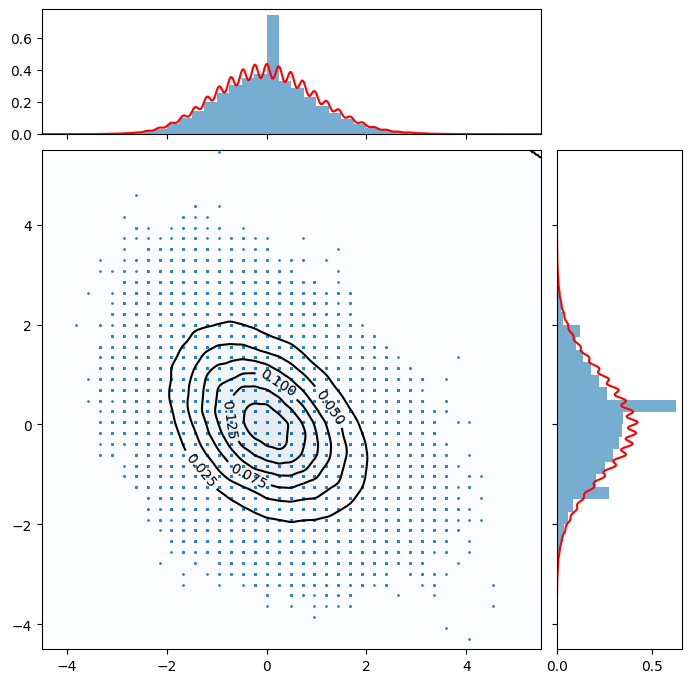

In [14]:
# Assuming Traj is a 3D numpy array
# Reshape x and y to 1D arrays if they are not already.
x = Traj[:,:,0].ravel()
y = Traj[:,:,1].ravel()

# Start with a square Figure.
fig = plt.figure(figsize=(8, 8))

# Add a gridspec with two rows and two columns
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)

# Create the Axes for scatter plot and marginal histograms.
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

# Draw the scatter plot and marginals using the scatter_hist function.
scatter_hist(x, y, ax, ax_histx, ax_histy)

# Display plot
plt.show()

In [15]:
# Defining Loss functions
LAGS = 400
N = 400
loss_acf_fft = make_loss('acf[fft]', target, lags=LAGS, device=device)
loss_acf_sec_moment = make_loss('acf[fft]', target**2, lags=LAGS, device=device)
loss_acf_bruteforce = make_loss('acf[bruteforce]', target, lags=LAGS, device=device)
loss_acf_randbrute = make_loss('acf[randombrute]', target, lags=LAGS, sample_lags=20, device=device)

loss_ccf_fft = make_loss('ccf[fft]', target, lags=LAGS, device=device)
loss_ccf_sec_moment = make_loss('ccf[fft]', target**2, lags=LAGS, device=device)
loss_ccf_bruteforce = make_loss('ccf[bruteforce]', target, lags=LAGS, device=device)
loss_ccf_randbrute = make_loss('ccf[randombrute]', target, lags=LAGS, sample_lags=20, device=device)

loss_pdf_empirical1 = make_loss('pdf', target, lower=-5, upper=5, n=N, bw=None, device=device)
loss_pdf_empirical2 = make_loss('pdf6', target, lower=-10, upper=10, n=N, bw=None, device=device)
loss_pdf_empirical2D = make_loss('pdf2D', target, lower=-5, upper=5, n=N, bw=None, device=device)

torch.Size([400, 2])


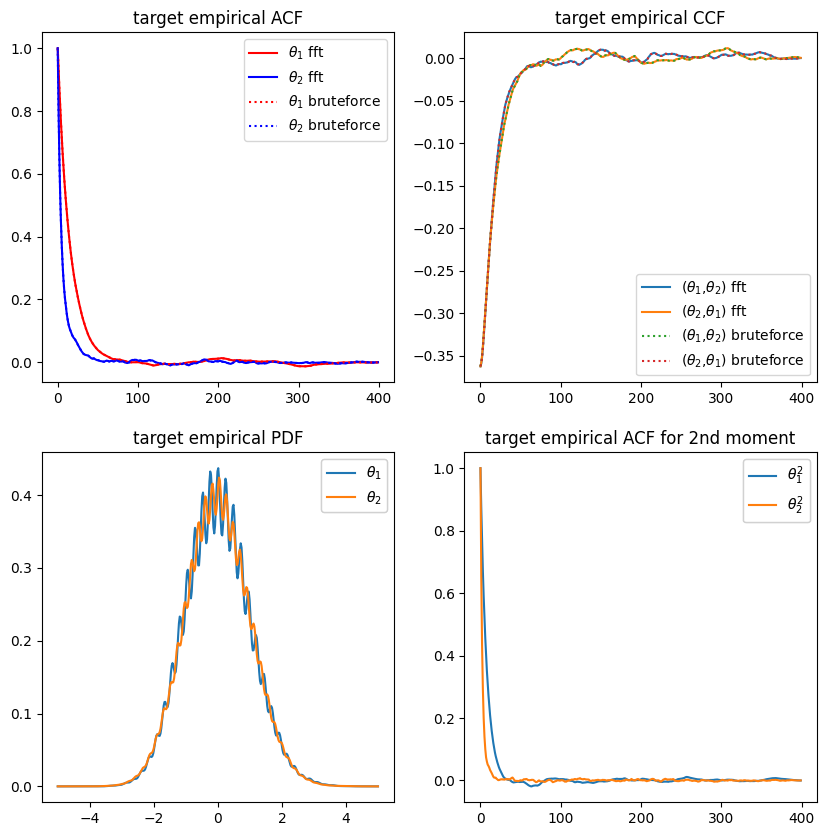

In [16]:
# Plotting target ACFs and PDF
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs[0,0].plot(loss_acf_fft._target.cpu()[...,0],'r', label=r'$\theta_1$ fft')
axs[0,0].plot(loss_acf_fft._target.cpu()[...,-1],'b', label=r'$\theta_2$ fft')
axs[0,0].plot(loss_acf_bruteforce._target.cpu()[...,0],'r:', label= r'$\theta_1$ bruteforce')
axs[0,0].plot(loss_acf_bruteforce._target.cpu()[...,1], 'b:', label=r'$\theta_2$ bruteforce')
axs[0,0].legend()
axs[0,0].set_title('target empirical ACF')

axs[0,1].plot(loss_ccf_fft._target.cpu()[...,0], label=r'($\theta_1$,$\theta_2$) fft')
axs[0,1].plot(loss_ccf_fft._target.cpu()[...,1], label=r'($\theta_2$,$\theta_1$) fft')
axs[0,1].plot(loss_ccf_bruteforce._target.cpu()[...,0],':',label=r'($\theta_1$,$\theta_2$) bruteforce')
axs[0,1].plot(loss_ccf_bruteforce._target.cpu()[...,1],':',label=r'($\theta_2$,$\theta_1$) bruteforce')
axs[0,1].legend()
axs[0,1].set_title('target empirical CCF')

x_grid = np.linspace(-5,5,num=sec_length)
pdf = axs[1,0].plot(x_grid,loss_pdf_empirical1._target.cpu())
legend3 = axs[1,0].legend(iter(pdf), (r'$\theta_1$', r'$\theta_2$'), loc=1)
axs[1,0].add_artist(legend3)
axs[1,0].set_title('target empirical PDF')


print(loss_acf_sec_moment._target.cpu().size())
sec_moment = axs[1,1].plot(loss_acf_sec_moment._target.cpu())
legend4 = axs[1,1].legend(iter(sec_moment), (r'$\theta_1^2$', r'$\theta_2^2$'),loc=1)
axs[1,1].set_title('target empirical ACF for 2nd moment')
axs[1,1].add_artist(legend4)

plt.show()

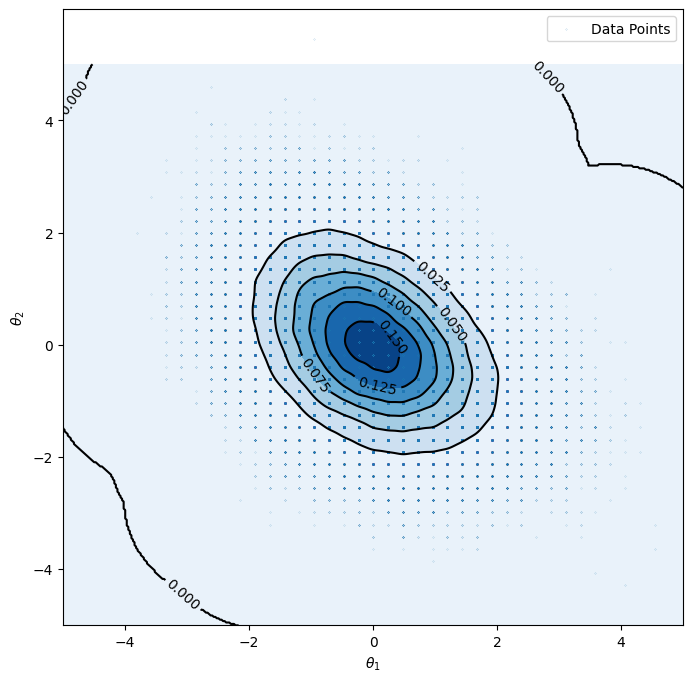

In [17]:
# Set the grid boundaries
xmin, xmax = -5, 5
ymin, ymax = -5, 5

# Create the grid for plotting
xx, yy = np.mgrid[xmin:xmax:400j, ymin:ymax:400j]
grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()])

# Compute KDE on the grid using your gauss_kde2D function
# kde_values = gauss_kde2D(data, lower=0, upper=0.5, n=400, bw=None)

# Convert torch output to numpy for plotting
kde_values_np = loss_pdf_empirical2D._target.cpu()



# Plotting
fig, ax = plt.subplots(figsize=(8, 8))

# Contourf plot
cfset = ax.contourf(xx, yy, kde_values_np, cmap='Blues')

# Contour plot
cset = ax.contour(xx, yy, kde_values_np, colors='k')

# Scatter plot of original data
ax.scatter(Traj[:,:,0], Traj[:,:,1], s=0.01, label='Data Points')

# Label the contour lines
ax.clabel(cset, inline=1, fontsize=10)
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
ax.legend()

plt.show()

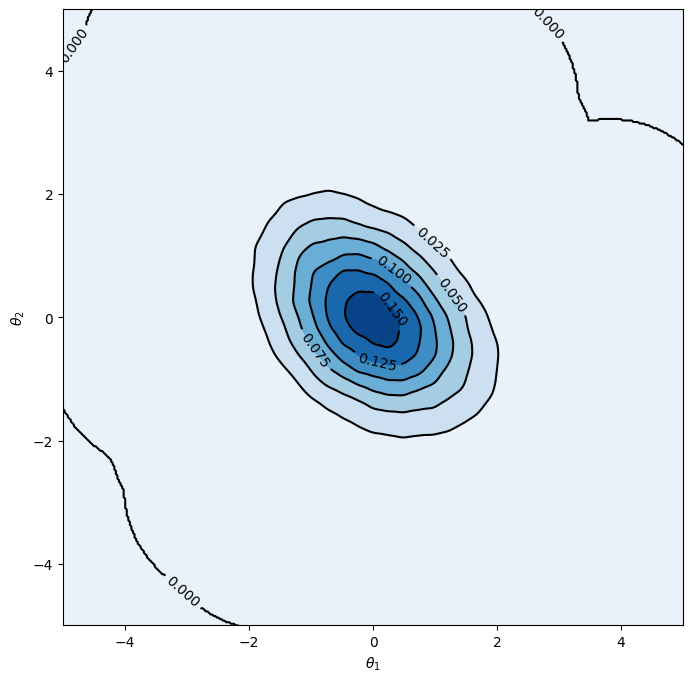

In [18]:
xmin, xmax = -5, 5
ymin, ymax = -5, 5

xx, yy = np.mgrid[xmin:xmax:400j, ymin:ymax:400j]
fig = plt.figure(figsize=(8, 8))
ax = fig.gca()
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Contourf plot
cfset = ax.contourf(xx, yy, loss_pdf_empirical2D._target.cpu(), cmap='Blues')
## Or kernel density estimate plot instead of the contourf plot

# Contour plot
cset = ax.contour(xx, yy, loss_pdf_empirical2D._target.cpu(), colors='k')
# Label plot
ax.clabel(cset, inline=1, fontsize=10)
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')

plt.show()

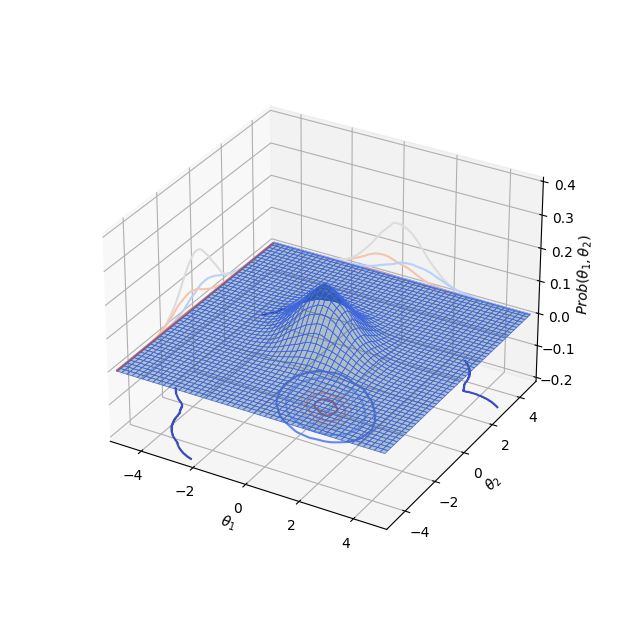

In [19]:
from mpl_toolkits.mplot3d import axes3d

ax = plt.figure(figsize=(8, 8)).add_subplot(projection='3d')
# fig = plt.figure()
# X, Y, Z = axes3d.get_test_data(0.05)

# Plot the 3D surface
ax.plot_surface(xx, yy, loss_pdf_empirical2D._target.cpu(), edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

# Plot projections of the contours for each dimension.  By choosing offsets
# that match the appropriate axes limits, the projected contours will sit on
# the 'walls' of the graph.
ax.contour(xx, yy, loss_pdf_empirical2D._target.cpu(), zdir='z', offset=-0.2, cmap='coolwarm')
ax.contour(xx, yy, loss_pdf_empirical2D._target.cpu(), zdir='x', offset=-5, cmap='coolwarm')
ax.contour(xx, yy, loss_pdf_empirical2D._target.cpu(), zdir='y', offset=5, cmap='coolwarm')

ax.set(xlim=(-5, 5), ylim=(-5, 5), zlim=(-0.2, 0.4),xlabel=r'$\theta_1$', ylabel=r'$\theta_2$', zlabel=r'$Prob(\theta_1,\theta_2)$')
ax.set_box_aspect(aspect=None, zoom=0.8)
plt.show()

Text(0.5, 1.0, 'target empirical PDF')

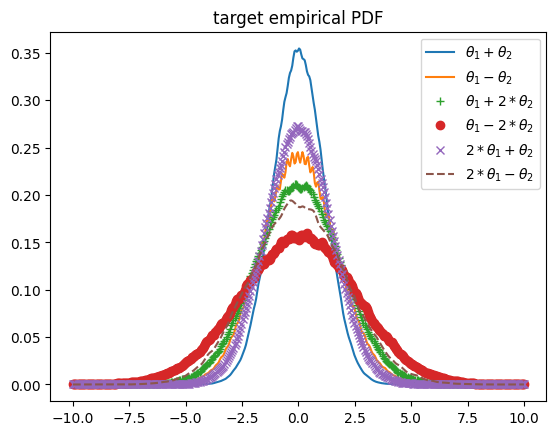

In [20]:
x_grid=np.linspace(-10, 10,num=sec_length)

plt.plot(x_grid, loss_pdf_empirical2._target.cpu()[...,0],label=r'$\theta_1+\theta_2$')
plt.plot(x_grid, loss_pdf_empirical2._target.cpu()[...,1],label=r'$\theta_1-\theta_2$')
plt.plot(x_grid, loss_pdf_empirical2._target.cpu()[...,2],'+',label=r'$\theta_1+2*\theta_2$')
plt.plot(x_grid, loss_pdf_empirical2._target.cpu()[...,3],'o',label=r'$\theta_1-2*\theta_2$')
plt.plot(x_grid, loss_pdf_empirical2._target.cpu()[...,4],'x',label=r'$2*\theta_1+\theta_2$')
plt.plot(x_grid, loss_pdf_empirical2._target.cpu()[...,5],'--',label=r'$2*\theta_1-\theta_2$')
plt.legend()
plt.title('target empirical PDF')

In [21]:
import time

In [22]:
class Model:
    def __init__(self, net):

        self.x_acf_s = None
        self.x_ccf_s = None
        self.x_pdf_s = None
        self.x_pdf2_s = None
        self.x_acf2_s = None
        self.s_collect = []

        self.net = net

        self.T_error=[]
        self.V_error=[]
        self.T_ccf=[]
        self.V_ccf=[]
        self.T_pdf=[]
        self.V_pdf=[]
        self.T_pdf2=[]
        self.V_pdf2=[]
        self.T_acf=[]
        self.V_acf=[]
        self.T_acf2=[]
        self.V_acf2=[]
        self.Step=[]
        self.iter = 0

    def train_U(self, x):
        return self.net(x)

    def predict_U(self, x):
        return self.train_U(x)

    def likelihood_loss(self, loss_acf, loss_ccf, loss_pdf, loss_pdf2, loss_acf2):
        loss = torch.reciprocal(2. * self.x_acf_s ** 2) * loss_acf.detach()      \
               + torch.reciprocal(2. * self.x_ccf_s ** 2) * loss_ccf.detach()    \
               + torch.reciprocal(2. * self.x_pdf_s ** 2) * loss_pdf.detach()    \
               + torch.reciprocal(2. * self.x_pdf2_s ** 2) * loss_pdf2.detach()  \
               + torch.reciprocal(2. * self.x_acf2_s ** 2) * loss_acf2.detach()  \
               + torch.log(self.x_acf_s * self.x_ccf_s * self.x_pdf_s * self.x_pdf2_s * self.x_acf2_s)
        return loss

    def true_loss(self, loss_acf, loss_ccf, loss_pdf, loss_pdf2, loss_acf2):
        return torch.reciprocal(2. * self.x_acf_s.detach() ** 2) * loss_acf + torch.reciprocal(2. * self.x_ccf_s.detach() ** 2) * loss_ccf + torch.reciprocal(2. * self.x_pdf_s.detach() ** 2) * loss_pdf + torch.reciprocal(2. * self.x_pdf2_s.detach() ** 2) * loss_pdf2 + torch.reciprocal(2. * self.x_acf2_s.detach() ** 2) * loss_acf2

    def run_baseline(self):
        optimizer_adam = optim.Adam(self.net.parameters(), lr=1e-3)
        for step in range(20000):
            optimizer_adam.zero_grad()
            ini = np.random.randn(2*sec_length, batch*self.net.lstm.input_size).astype(np.float32) 
            input = torch.from_numpy(ini.reshape(2*sec_length, batch, self.net.lstm.input_size)).to(device)
            prediction, _ = self.train_U(input)
            prediction = prediction[-LAGS:,:,:]
            loss = loss_acf_fft(prediction)+ loss_ccf_fft(prediction)+loss_pdf_empirical1(prediction)+loss_pdf_empirical2(prediction)+loss_acf_sec_moment(prediction**2)
            loss.backward()
            optimizer_adam.step()
            self.iter += 1
            if step % 50 == 0: 
                with torch.no_grad():
                    loss = loss_acf_fft(prediction)+loss_ccf_fft(prediction)+loss_pdf_empirical1(prediction)+loss_pdf_empirical2(prediction)+loss_acf_sec_moment(prediction**2)
                    pred_val, _ = self.predict_U(val_set)
                    pred_val = pred_val[-LAGS:,:,:]
                    loss_val = loss_acf_bruteforce(pred_val)+loss_ccf_bruteforce(pred_val)+ loss_pdf_empirical1(pred_val)+ loss_pdf_empirical2(pred_val) + loss_acf_sec_moment(pred_val**2)
                    acf = loss_acf_bruteforce(pred_val)
                    ccf = loss_ccf_bruteforce(pred_val)
                    pdf = loss_pdf_empirical1(pred_val)
                    pdf2 = loss_pdf_empirical2(pred_val)
                    acf_sec_moment = loss_acf_sec_moment(pred_val**2)
                    print('[%d]-th step loss: %.4f, %.4f, acf: %.5f, ccf: %.5f, pdf: %.5f, pdf2: %.5f, acf2: %.5f' % (step, loss, loss_val, acf, ccf, pdf, pdf2, acf_sec_moment))
                    self.T_acf.append(loss_acf_fft(prediction).detach().cpu().numpy())
                    self.V_acf.append(loss_acf_bruteforce(pred_val).detach().cpu().numpy())
                    self.T_ccf.append(loss_ccf_fft(prediction).detach().cpu().numpy())
                    self.V_ccf.append(loss_ccf_bruteforce(pred_val).detach().cpu().numpy())
                    self.T_pdf.append(loss_pdf_empirical1(prediction).detach().cpu().numpy())
                    self.V_pdf.append(loss_pdf_empirical1(pred_val).detach().cpu().numpy())
                    self.T_pdf2.append(loss_pdf_empirical2(prediction).detach().cpu().numpy())
                    self.V_pdf2.append(loss_pdf_empirical2(pred_val).detach().cpu().numpy())
                    self.T_acf2.append(loss_acf_sec_moment(prediction**2).detach().cpu().numpy())
                    self.V_acf2.append(loss_acf_sec_moment(pred_val**2).detach().cpu().numpy())
                    self.T_error.append(loss.detach().cpu().numpy())
                    self.V_error.append(loss_val.detach().cpu().numpy())
                    self.Step.append(step)
            if loss <=0.0003 and loss_val <=0.0003:
                break

        if loss > 0.0003 and loss_val > 0.0003:
            print ('Training failed')
        print('Training finished')



    def run_AW(self):
        self.x_acf_s = nn.Parameter(self.x_acf_s, requires_grad=True)
        self.x_ccf_s = nn.Parameter(self.x_ccf_s, requires_grad=True)
        self.x_pdf_s = nn.Parameter(self.x_pdf_s, requires_grad=True)
        self.x_pdf2_s = nn.Parameter(self.x_pdf2_s, requires_grad=True)
        self.x_acf2_s = nn.Parameter(self.x_acf2_s, requires_grad=True)


        optimizer_adam = optim.Adam(self.net.parameters(), lr=1e-3)
        optimizer_adam_weight = optim.Adam([self.x_acf_s] + [self.x_ccf_s] + [self.x_pdf_s] + [self.x_pdf2_s] + [self.x_acf2_s],
                                                     lr=1e-3)

        for step in range(20000):
            self.s_collect.append([self.iter, self.x_acf_s.item(), self.x_ccf_s.item(), self.x_pdf_s.item(), self.x_pdf2_s.item(), self.x_acf2_s.item()])

            optimizer_adam.zero_grad()
            ini = np.random.randn(2*sec_length, batch*self.net.lstm.input_size).astype(np.float32) 
            input = torch.from_numpy(ini.reshape(2*sec_length, batch, self.net.lstm.input_size)).to(device)
            prediction, _ = self.train_U(input)
            prediction = prediction[-LAGS:,:,:]
            loss = self.true_loss(loss_acf_fft(prediction), loss_ccf_fft(prediction),loss_pdf_empirical1(prediction),loss_pdf_empirical2(prediction),loss_acf_sec_moment(prediction**2))
            loss.backward()
            optimizer_adam.step()
            self.iter += 1
            if step % 50 == 0: 
                with torch.no_grad():
                    loss = loss_acf_fft(prediction)+loss_ccf_fft(prediction)+loss_pdf_empirical1(prediction)+loss_pdf_empirical2(prediction)+loss_acf_sec_moment(prediction**2)
                    pred_val, _ = self.predict_U(val_set)
                    pred_val = pred_val[-LAGS:,:,:]
                    loss_val = loss_acf_bruteforce(pred_val)+loss_ccf_bruteforce(pred_val)+ loss_pdf_empirical1(pred_val) + loss_pdf_empirical2(pred_val) + loss_acf_sec_moment(pred_val**2)
                    acf = loss_acf_bruteforce(pred_val)
                    ccf = loss_ccf_bruteforce(pred_val)
                    pdf = loss_pdf_empirical1(pred_val)
                    pdf2 = loss_pdf_empirical2(pred_val)
                    acf_sec_moment = loss_acf_sec_moment(pred_val**2)
                    print('[%d]-th step loss: %.4f, %.4f, acf: %.5f, ccf: %.5f, pdf: %.5f, pdf2: %.5f, acf2: %.5f' % (step, loss, loss_val, acf, ccf, pdf, pdf2, acf_sec_moment))
                    self.T_acf.append(loss_acf_fft(prediction).detach().cpu().numpy())
                    self.V_acf.append(loss_acf_bruteforce(pred_val).detach().cpu().numpy())
                    self.T_ccf.append(loss_ccf_fft(prediction).detach().cpu().numpy())
                    self.V_ccf.append(loss_ccf_bruteforce(pred_val).detach().cpu().numpy())
                    self.T_pdf.append(loss_pdf_empirical1(prediction).detach().cpu().numpy())
                    self.V_pdf.append(loss_pdf_empirical1(pred_val).detach().cpu().numpy())
                    self.T_pdf2.append(loss_pdf_empirical2(prediction).detach().cpu().numpy())
                    self.V_pdf2.append(loss_pdf_empirical2(pred_val).detach().cpu().numpy())
                    self.T_acf2.append(loss_acf_sec_moment(prediction**2).detach().cpu().numpy())
                    self.V_acf2.append(loss_acf_sec_moment(pred_val**2).detach().cpu().numpy())
                    self.T_error.append(loss.detach().cpu().numpy())
                    self.V_error.append(loss_val.detach().cpu().numpy())
                    self.Step.append(step)
            if loss <=0.0003 and loss_val <=0.0003:
                break
            optimizer_adam_weight.zero_grad()
            loss = self.likelihood_loss(loss_acf_fft(prediction), loss_ccf_fft(prediction),loss_pdf_empirical1(prediction),loss_pdf_empirical2(prediction),loss_acf_sec_moment(prediction**2))
            loss.backward()
            optimizer_adam_weight.step()
            
        if loss > 0.0003 and loss_val > 0.0003:
            print ('Training failed')
        print('Training finished')


    def train(self):
        self.x_acf_s = torch.tensor(2.).float()
        self.x_ccf_s = torch.tensor(2.).float()
        self.x_pdf_s = torch.tensor(2.).float()
        self.x_pdf2_s = torch.tensor(2.).float()
        self.x_acf2_s = torch.tensor(2.).float()
        start_time = time.time()
        if model_type == 0:
            self.run_baseline()
        elif model_type == 1:
            self.run_AW()
        elapsed = time.time() - start_time
        print('Training time: %.2f' % elapsed)
        avg_time = elapsed/self.iter
        print('Training time per iteration: %.2f' % avg_time)
        print('Number of Iterations:%d' %self.iter)

In [23]:
model_type = 1

In [24]:
### Defining SINN model
net = SINN(2, 10, 2, 2).to(device)
AWmodel = Model(net=net)

In [25]:
AWmodel.train()

[0]-th step loss: 0.4208, 0.4197, acf: 0.00507, ccf: 0.01321, pdf: 0.26153, pdf2: 0.13915, acf2: 0.00078
[50]-th step loss: 0.3138, 0.3062, acf: 0.00338, ccf: 0.00236, pdf: 0.20866, pdf2: 0.09081, acf2: 0.00095
[100]-th step loss: 0.0454, 0.0441, acf: 0.00215, ccf: 0.00569, pdf: 0.02217, pdf2: 0.01266, acf2: 0.00147
[150]-th step loss: 0.0218, 0.0211, acf: 0.00137, ccf: 0.00477, pdf: 0.00928, pdf2: 0.00442, acf2: 0.00129
[200]-th step loss: 0.0108, 0.0108, acf: 0.00084, ccf: 0.00305, pdf: 0.00415, pdf2: 0.00182, acf2: 0.00091
[250]-th step loss: 0.0062, 0.0060, acf: 0.00056, ccf: 0.00131, pdf: 0.00243, pdf2: 0.00108, acf2: 0.00066
[300]-th step loss: 0.0036, 0.0036, acf: 0.00035, ccf: 0.00033, pdf: 0.00159, pdf2: 0.00074, acf2: 0.00057
[350]-th step loss: 0.0027, 0.0027, acf: 0.00032, ccf: 0.00023, pdf: 0.00119, pdf2: 0.00051, acf2: 0.00049
[400]-th step loss: 0.0022, 0.0023, acf: 0.00030, ccf: 0.00017, pdf: 0.00097, pdf2: 0.00040, acf2: 0.00043
[450]-th step loss: 0.0019, 0.0019, acf:

In [26]:
def draw_loss(model):
    ### Plotting the training and the generalization error
    fig = plt.figure(1)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title("Error plot",fontsize=15) 
    plt.yscale('log')
    plt.plot(model.Step, model.T_error,'r',label='Training error')
    plt.plot(model.Step, model.V_error,'b--',label='Validation error')
    plt.xlabel(r'Training times $n$',fontsize=15)
    plt.ylabel(r'$l_2$',fontsize=15)
    plt.legend(frameon=False,fontsize=15)

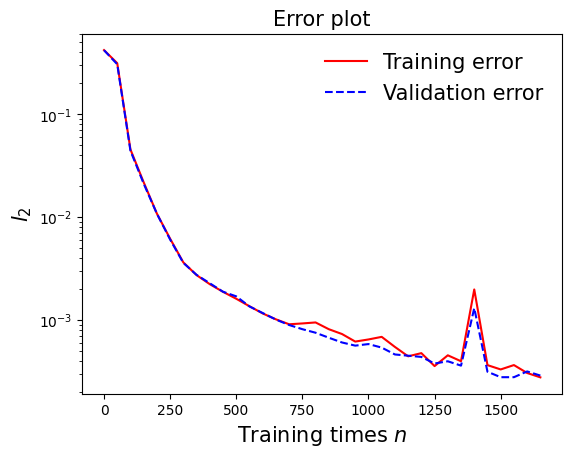

In [27]:
draw_loss(AWmodel)

In [28]:
def draw_errors(model):
    ### Plotting the training and the generalization error
    fig = plt.figure(1)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title("Error plot for loss functions w/o coeff",fontsize=15)
    plt.yscale('log')
    plt.plot(model.Step, model.T_error,'k',label='Training error')
    plt.plot(model.Step, model.V_error,'k--')
    plt.plot(model.Step, model.T_acf,'r',label='acf error')
    plt.plot(model.Step, model.V_acf,'r--')
    plt.plot(model.Step, model.T_ccf,'b',label='ccf error')
    plt.plot(model.Step, model.V_ccf,'b--')
    plt.plot(model.Step, model.T_pdf,'y',label='pdf error')
    plt.plot(model.Step, model.V_pdf,'y--')
    plt.plot(model.Step, model.T_pdf2,'m',label=r'$pdf_{combo}$ error')
    plt.plot(model.Step, model.V_pdf2,'m--')
    plt.plot(model.Step, model.T_acf2,'g',label=r'$acf(\tilde{q}^2)$ error')
    plt.plot(model.Step, model.V_acf2,'g--')

    plt.xlabel(r'Training times $n$',fontsize=15)
    plt.ylabel(r'$l_1+l_2$',fontsize=15)
    plt.legend(frameon=False,fontsize=15, bbox_to_anchor=(1.1, 1.05))

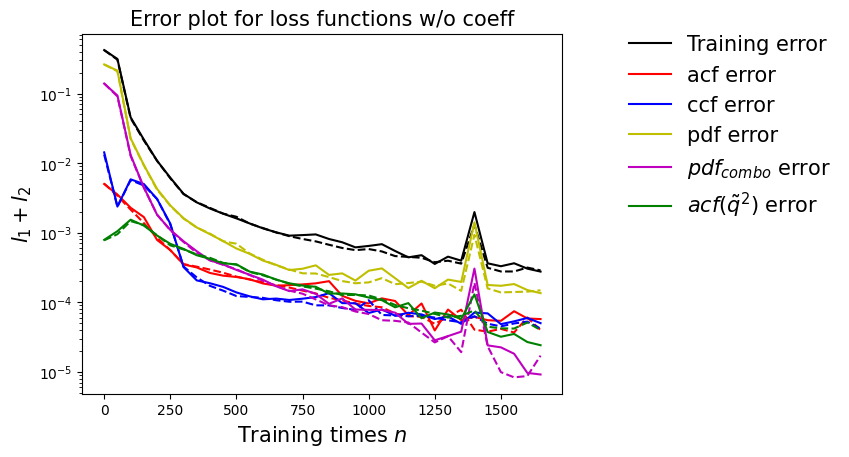

In [29]:
draw_errors(AWmodel)

In [30]:
def draw_adaptive_w(model):
    s_collect = np.array(model.s_collect)
    np.savetxt('s_RAM-AW.npy', s_collect)
    plt.plot(s_collect[:, 0], s_collect[:, 1], 'r-', label=r'$\sigma_{acf}$')
    plt.plot(s_collect[:, 0], s_collect[:, 2], 'b-', label=r'$\sigma_{ccf}$')
    plt.plot(s_collect[:, 0], s_collect[:, 3], 'y-', label=r'$\sigma_{pdf}$')
    plt.plot(s_collect[:, 0], s_collect[:, 4], 'm-', label=r'$\sigma_{pdf_{combo}}$')
    plt.plot(s_collect[:, 0], s_collect[:, 5], 'g-', label=r'$\sigma_{acf2}$')
    plt.xlabel(r'Iterations $n$')
    plt.ylabel(r'$\sigma$')
    plt.legend()
    plt.show()

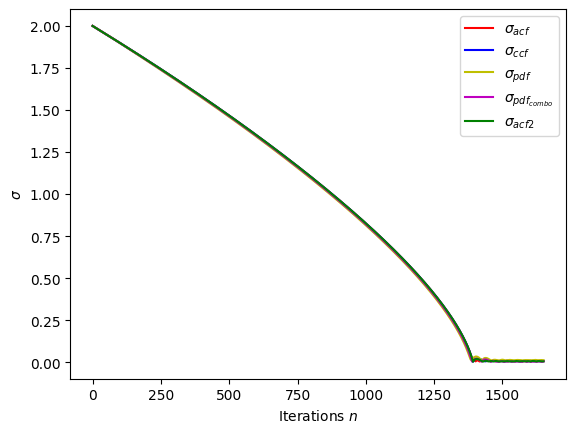

In [31]:
draw_adaptive_w(AWmodel)

In [32]:
def draw_epoch_w(model):
    s_collect = np.array(model.s_collect)
    np.savetxt('s_RAM-AW.npy', s_collect)
    plt.yscale('log')
    plt.plot(s_collect[:, 0], np.reciprocal(2. * s_collect[:, 1]**2), 'r-', label=r'$\frac{1}{2\sigma_{acf(\tilde{q})}^2}$')
    plt.plot(s_collect[:, 0], np.reciprocal(2. * s_collect[:, 2]**2), 'b-', label=r'$\frac{1}{2\sigma_{ccf(\tilde{q})}^2}$')
    plt.plot(s_collect[:, 0], np.reciprocal(2. * s_collect[:, 3]**2), 'y-', label=r'$\frac{1}{2\sigma_{pdf}^2}$')
    plt.plot(s_collect[:, 0], np.reciprocal(2. * s_collect[:, 4]**2), 'm-', label=r'$\frac{1}{2\sigma_{pdf_{combo}}^2}$')
    plt.plot(s_collect[:, 0], np.reciprocal(2. * s_collect[:, 5]**2), 'g-', label=r'$\frac{1}{2\sigma_{acf(\tilde{q}^2)}^2}$')
    plt.xlabel(r'Iterations $n$',fontsize=15)
    plt.ylabel('Weights',fontsize=15)
    plt.legend(frameon=False,fontsize=14,loc=4)
    plt.show()

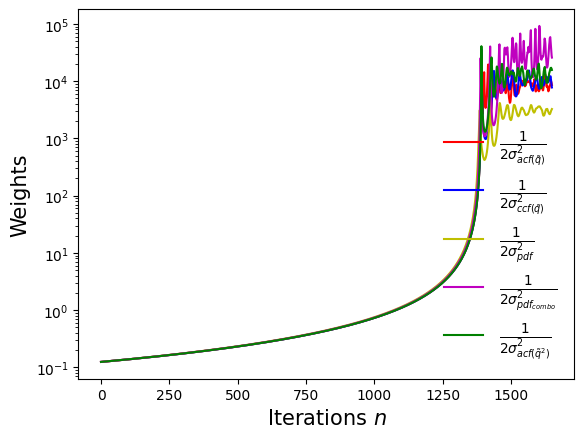

In [33]:
draw_epoch_w(AWmodel)

In [34]:
def test1(model):
    ran_input=torch.randn(input.size(),dtype=input.dtype,layout=input.layout, device=input.device)
    Pred,_= model.predict_U(ran_input)
    prediction=Pred[-sec_length:,:,:].detach().cpu().numpy().reshape(sec_length, batch, 2)
    # Test 1: plot the sample path generated by SINN and the exact sample path 
    skip = 0

    fig = plt.figure(0)
    plt.title("KMC sample trajectories",fontsize=15) 
    plt.plot(Traj[:, 0])
    plt.xlabel(r'$t$',fontsize=15)
    plt.ylabel(r'$\theta_1$ and $\theta_2$',fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15) 


    fig = plt.figure(1)
    plt.title("SINN trajectories",fontsize=15)    
    plt.plot(prediction[:, 0])
    plt.xlabel(r'$t$',fontsize=15)
    plt.ylabel(r'$\theta_1$ and $\theta_2$',fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

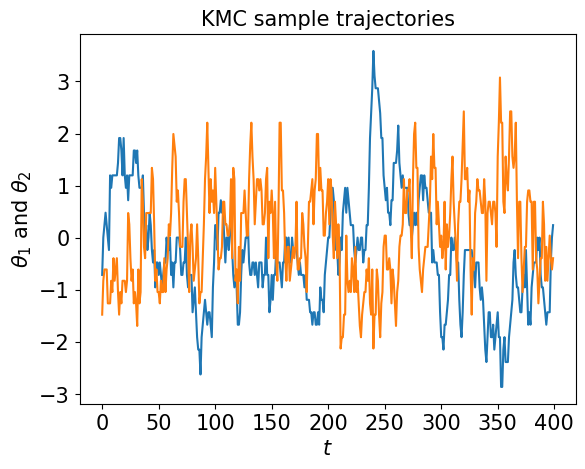

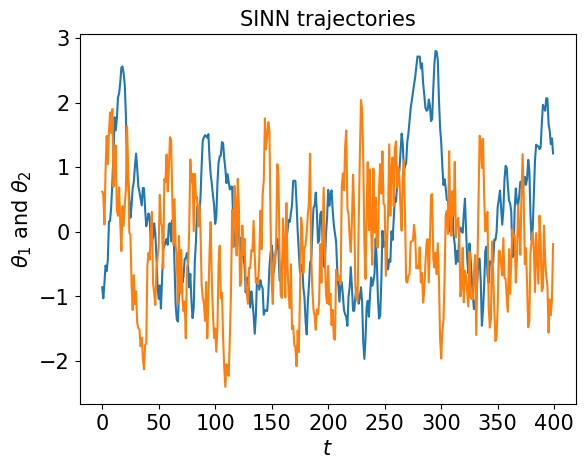

In [35]:
test1(AWmodel)

In [36]:
def test2(model):
    ran_input=torch.randn(input.size(),dtype=input.dtype,layout=input.layout, device=input.device)
    Pred,_= model.predict_U(ran_input)
    
    # Test 2: plot the CCF of the sample path generated by the SINN and the exact CCF  
    acf_p=StatLoss.acf(Pred[-sec_length:,:,:])
    acf_t=StatLoss.acf(target)
    corr_p1=acf_p.detach().cpu().numpy()
    corr_t1=acf_t.detach().cpu().numpy()
    ccf_p=StatLoss.ccf(Pred[-sec_length:,:,:])
    ccf_t=StatLoss.ccf(target)
    corr_p2=ccf_p.detach().cpu().numpy()
    corr_t2=ccf_t.detach().cpu().numpy()
    
    fig = plt.figure(0)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title(r'Normalized ACF of $\theta_1$',fontsize=15)    
    plt.plot(corr_t1[...,0],'r',label='Exact')        # correlation function of the target 
    plt.plot(corr_p1[...,0], 'b--',label='SINN')        # Correlation function after the training      # Correlation function after the training 
    plt.xlabel(r'$t$',fontsize=15)
    plt.ylabel(r'$C(t)/C(0)$',fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks([-0.2,0,0.2,0.4,0.6,0.8,1.0],fontsize=15)
    plt.legend()
    
    fig = plt.figure(1)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title(r'Normalized ACF of $\theta_2$',fontsize=15)          
    plt.plot(corr_t1[...,-1],'r',label='Exact')        # correlation function of the target 
    plt.plot(corr_p1[...,-1], 'b--',label='SINN')     # Correlation function after the training      # Correlation function after the training 
    plt.xlabel(r'$t$',fontsize=15)
    plt.ylabel(r'$C(t)/C(0)$',fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks([-0.2,0,0.2,0.4,0.6,0.8,1.0],fontsize=15)
    plt.legend()
    
    fig = plt.figure(2)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title(r'Normalized CCF',fontsize=15)    
    plt.plot(corr_t2[:,:],'r')        # correlation function of the target 
    plt.plot(corr_p2[:,:], 'b--')        # Correlation function after the training      # Correlation function after the training 
    plt.xlabel(r'$t$',fontsize=15)
    plt.ylabel(r'$C(t)/C(0)$',fontsize=15)
    plt.xticks(fontsize=15)

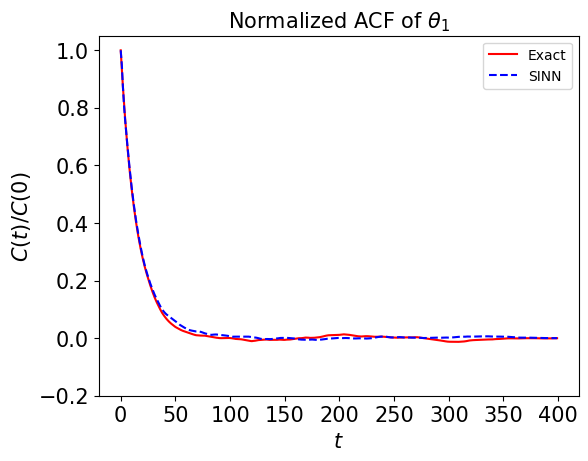

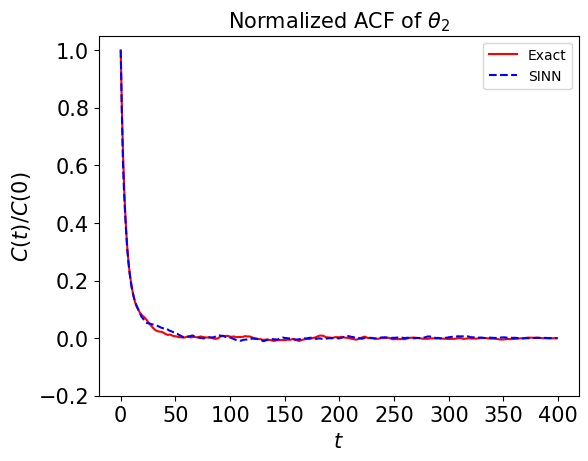

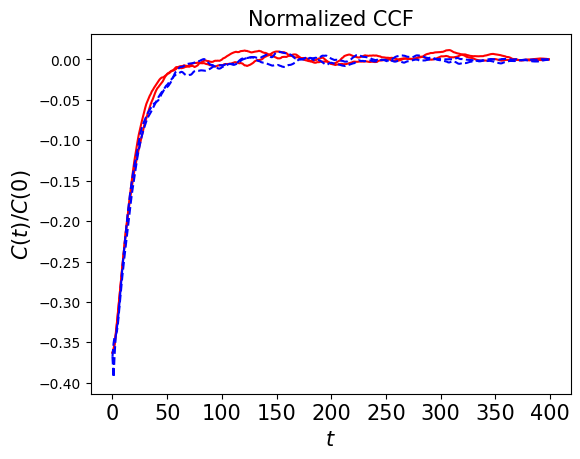

In [37]:
test2(AWmodel)

In [38]:
def test3(model):
    ran_input=torch.randn(input.size(),dtype=input.dtype,layout=input.layout, device=input.device)
    Pred,_= model.predict_U(ran_input)
    
    # Test 3: plot the PDF of the sample path generated by SINN and the exact PDF  
    rho_data =  StatLoss.gauss_kde(target, -5, 5, 400, None).cpu()
    rho_input = StatLoss.gauss_kde(ran_input, -5, 5, 400, None).cpu()
    rho_prediction = StatLoss.gauss_kde(Pred[-sec_length:,:,:].detach(), -5, 5, 400, None).cpu()
    
    rho_data2 =  StatLoss.gauss_kde6(target, -10, 10, 400, None).cpu()
    rho_prediction2 = StatLoss.gauss_kde6(Pred[-sec_length:,:,:].detach(), -10, 10, 400, None).cpu()


    x=np.linspace(-5, 5, 400)
    fig = plt.figure(0)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title(r"Equilibrium probability density function",fontsize=15)    
    plt.plot(x, rho_data.numpy()[...,0],label=r'Exact PDF of $\theta_1$')    # target PDF
    plt.plot(x, rho_data.numpy()[...,1],label=r'Exact PDF of $\theta_2$')    # target PDF
    plt.plot(x, rho_prediction.numpy()[...,0], ':',label=r'PDF of the output $\theta_1$')  # PDF after the training 
    plt.plot(x, rho_prediction.numpy()[...,1], ':',label=r'PDF of the output $\theta_2$')  # PDF after the training 
#     plt.xlim(0,0.5)
#     plt.ylim(0,5)
    plt.xlabel(r'$x$',fontsize=15)
    plt.ylabel(r'$\rho(x)$',fontsize=15)
    plt.legend(frameon=False,fontsize=10)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    
    x=np.linspace(-10, 10, 400) 
    fig = plt.figure(1)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title(r"Equilibrium probability density function of sum and diff",fontsize=15)    
    plt.plot(x, rho_data2.numpy()[...,0],label=r'Exact PDF of $\theta_1+\theta_2$')    # target PDF
    plt.plot(x, rho_data2.numpy()[...,1],label=r'Exact PDF of $\theta_1-\theta_2$')    # target PDF
    plt.plot(x, rho_prediction2.numpy()[...,0], ':',label=r'PDF of the output $\theta_1+\theta_2$')  # PDF after the training 
    plt.plot(x, rho_prediction2.numpy()[...,1], ':',label=r'PDF of the output $\theta_1-\theta_2$')  # PDF after the training 
#     plt.xlim(-2,2.5)
#     plt.ylim(0,5)
    plt.xlabel(r'$x$',fontsize=15)
    plt.ylabel(r'$\rho(x)$',fontsize=15)
    plt.legend(frameon=False,fontsize=10)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    
    fig = plt.figure(2)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title(r"Equilibrium probability density function of sum and diff",fontsize=15)    
    plt.plot(x, rho_data2.numpy()[...,2],label=r'Exact PDF of $\theta_1+2\theta_2$')    # target PDF
    plt.plot(x, rho_data2.numpy()[...,3],label=r'Exact PDF of $\theta_1-2\theta_2$')    # target PDF
    plt.plot(x, rho_prediction2.numpy()[...,2], ':',label=r'PDF of the output $\theta_1+2\theta_2$')  # PDF after the training 
    plt.plot(x, rho_prediction2.numpy()[...,3], ':',label=r'PDF of the output $\theta_1-2\theta_2$')  # PDF after the training 
#     plt.xlim(-2,2.5)
#     plt.ylim(0,5)
    plt.xlabel(r'$x$',fontsize=15)
    plt.ylabel(r'$\rho(x)$',fontsize=15)
    plt.legend(frameon=False,fontsize=10)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    
    fig = plt.figure(3)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title(r"Equilibrium probability density function of sum and diff",fontsize=15)    
    plt.plot(x, rho_data2.numpy()[...,4],label=r'Exact PDF of $2\theta_1+\theta_2$')    # target PDF
    plt.plot(x, rho_data2.numpy()[...,5],label=r'Exact PDF of $2\theta_1-\theta_2$')    # target PDF
    plt.plot(x, rho_prediction2.numpy()[...,4], ':',label=r'PDF of the output $2\theta_1+\theta_2$')  # PDF after the training 
    plt.plot(x, rho_prediction2.numpy()[...,5], ':',label=r'PDF of the output $2\theta_1-\theta_2$')  # PDF after the training 
#     plt.xlim(-2,2.5)
#     plt.ylim(0,5)
    plt.xlabel(r'$x$',fontsize=15)
    plt.ylabel(r'$\rho(x)$',fontsize=15)
    plt.legend(frameon=False,fontsize=10)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

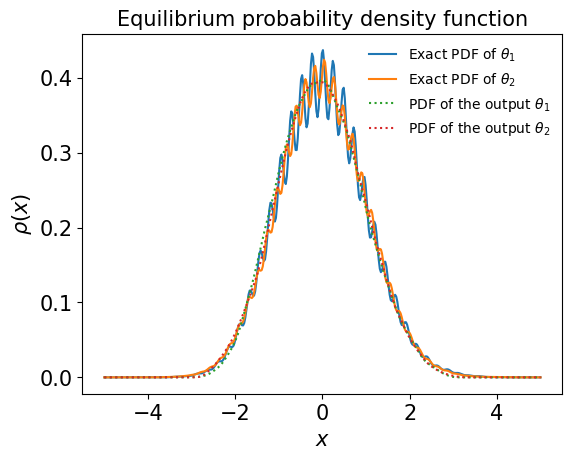

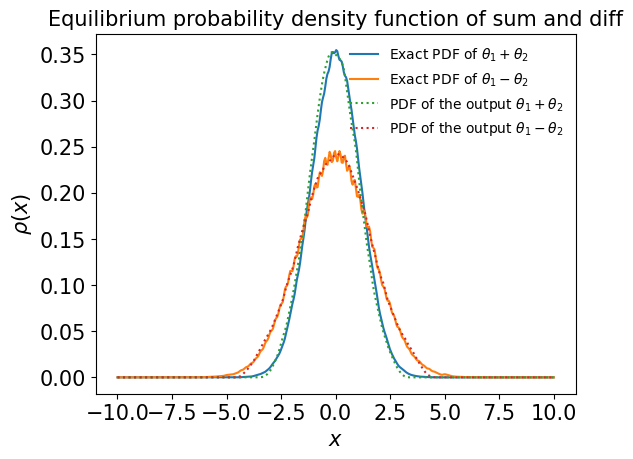

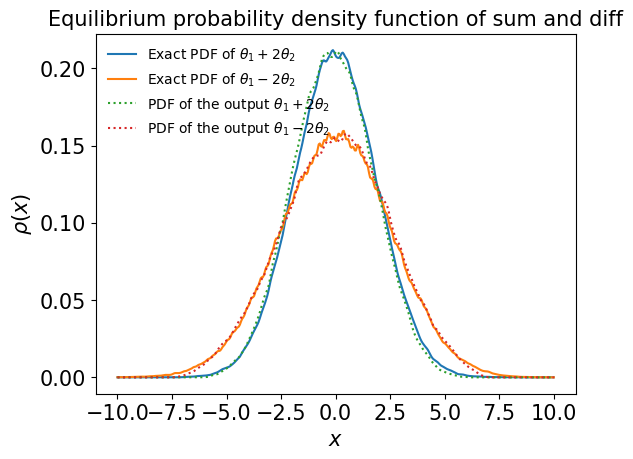

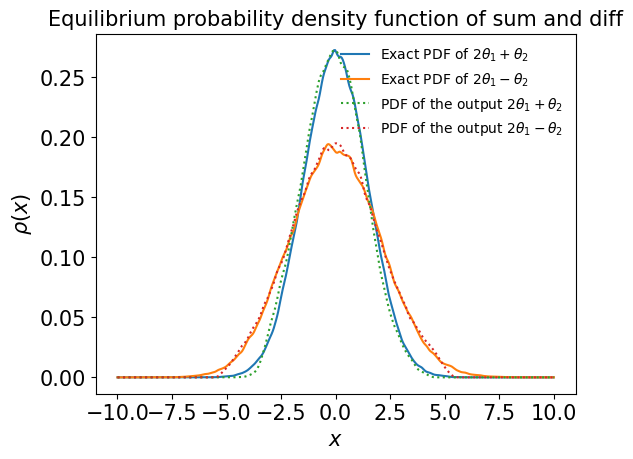

In [39]:
test3(AWmodel)

In [40]:
def test4(model):
    ran_input=torch.randn(input.size(),dtype=input.dtype,layout=input.layout, device=input.device)
    Pred,_= model.predict_U(ran_input)
    prediction=Pred[-sec_length:,:,:].detach().cpu().numpy().reshape(sec_length, batch, 2)
    
    # Test 4: Comparing the higher-order ACF
    acf2=StatLoss.acf(target**2)
    pred_norm=torch.from_numpy((prediction).reshape(sec_length, batch,2))
    acf2_app=StatLoss.acf(pred_norm**2)

    
    fig = plt.figure(0)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title(r'Normalized ACF of $\theta_1^2$',fontsize=15)    
    plt.plot(acf2.detach().cpu().numpy()[...,0],'r',label='Exact')        # correlation function of the target 
    plt.plot(acf2_app.detach().cpu().numpy()[...,0], 'b--',label='SINN')        # Correlation function after the training      # Correlation function after the training 
    plt.xlabel(r'$t$',fontsize=15)
    plt.ylabel(r'$C(t)/C(0)$',fontsize=15)
    plt.xticks(fontsize=15)
    
    plt.yticks([-0.2,0,0.2,0.4,0.6,0.8,1.0],fontsize=15)
    plt.legend()
    
    fig = plt.figure(1)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title(r'Normalized ACF of $\theta_2^2$',fontsize=15)          
    plt.plot(acf2.detach().cpu().numpy()[...,1],'r',label='Exact')        # correlation function of the target 
    plt.plot(acf2_app.detach().cpu().numpy()[...,1], 'b--',label='SINN')     # Correlation function after the training      # Correlation function after the training 
    plt.xlabel(r'$t$',fontsize=15)
    plt.ylabel(r'$C(t)/C(0)$',fontsize=15)
    plt.xticks(fontsize=15)
 
    plt.yticks([-0.2,0,0.2,0.4,0.6,0.8,1.0],fontsize=15)
    plt.legend()    

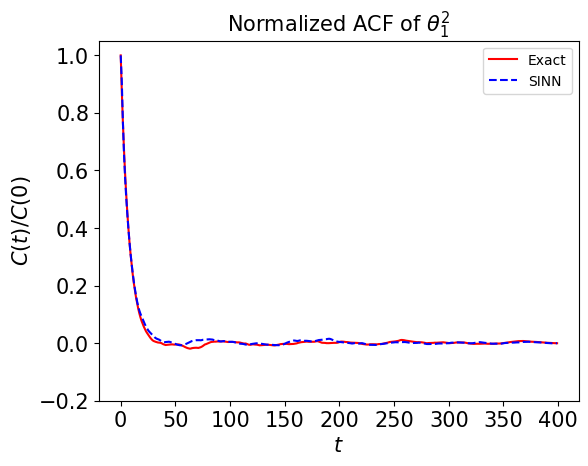

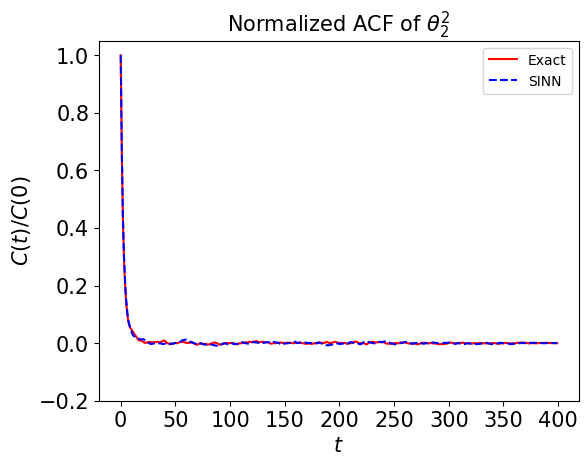

In [41]:
test4(AWmodel)

In [42]:
def test5(model):
    # Test 5: plot the expolation result, i.e. Prediction of the FPU-Langevin dynamics for longer time 
    [a,b,c]=input.size()
    skip=20
    scale=10
    burnin=3
    fold=800
    batch_new=50
    ran_input=torch.randn(((scale-burnin)*a,batch_new,c),dtype=input.dtype,layout=input.layout, device=input.device)
    Pred_L, _= model.predict_U(ran_input)
    prediction_ext=Pred_L.detach().cpu().numpy().reshape((scale-burnin)*a, batch_new,2)
    ccf_p=StatLoss.ccf(Pred_L,method='bruteforce')

#     LT=np.linspace(0,(scale-burnin)*a*delta_t,num=(scale-burnin)*a+1)
#     LT=LT[0:-1]


    fig = plt.figure(0)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
#     plt.title("Short-time trajectories",fontsize=15)
    plt.plot(traj_theta1[:,0],label='KMC')
    plt.plot(prediction_ext[-400:, 0, 0]*std1+mean1,'--',label='SINN output')
#     plt.xlim([0,80])
    plt.xlabel(r'$t$',fontsize=15)
    plt.ylabel(r'$\theta_1$',fontsize=15)
    plt.legend(frameon=False,fontsize=15)
    plt.yticks([0.22,0.235,0.25],fontsize=15)
    plt.xticks(fontsize=15)



    fig = plt.figure(figsize=(16, 4))
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title("Long-time trajectories",fontsize=15)
    plt.plot(traj_theta1[:,0],label='KMC simulation')
    plt.plot(prediction_ext[skip:, 0, 0]*std1+mean1,'--',label='SINN simulation')
#     plt.xlim([0,500])
    plt.xlabel(r'$t$',fontsize=15)
    plt.ylabel(r'$\theta_1$',fontsize=15)
    plt.legend(frameon=False,fontsize=15)
    plt.yticks([0.22,0.235,0.25],fontsize=15)
    plt.xticks(fontsize=15)

    fig = plt.figure(2)
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
#     plt.title("Short-time trajectories",fontsize=15)
    plt.plot(traj_theta2[:,0],label='KMC simulation')
    plt.plot(prediction_ext[-400:, 0, 1]*std2+mean2,'--',label='SINN simulation')
#     plt.xlim([0,80])
    plt.xlabel(r'$t$',fontsize=15)
    plt.ylabel(r'$\theta_2$',fontsize=15)
#     plt.legend(frameon=False,fontsize=15)
    plt.yticks([0.22,0.235,0.25],fontsize=15)
    plt.xticks(fontsize=15)



    fig = plt.figure(figsize=(16, 4))
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    plt.title("Long-time trajectories",fontsize=15)
    plt.plot(traj_theta2[:,0],label='KMC simulation')
    plt.plot(prediction_ext[skip:, 0, 1]*std2+mean2,'--',label='SINN simulation')
#     plt.xlim([0,500])
    plt.xlabel(r'$t$',fontsize=15)
    plt.ylabel(r'$\theta_2$',fontsize=15)
    plt.legend(frameon=False,fontsize=15)
    plt.yticks([0.22,0.235,0.25],fontsize=15)
    plt.xticks(fontsize=15)

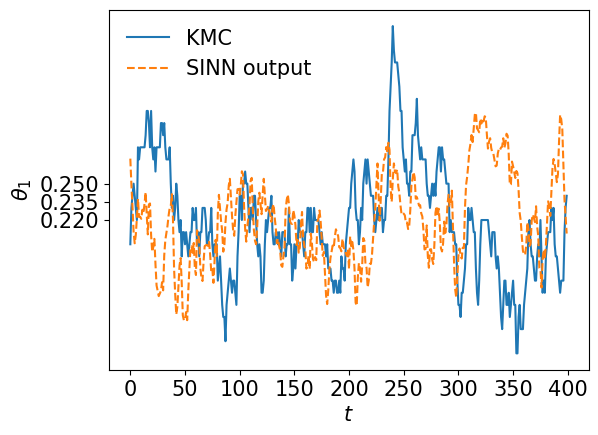

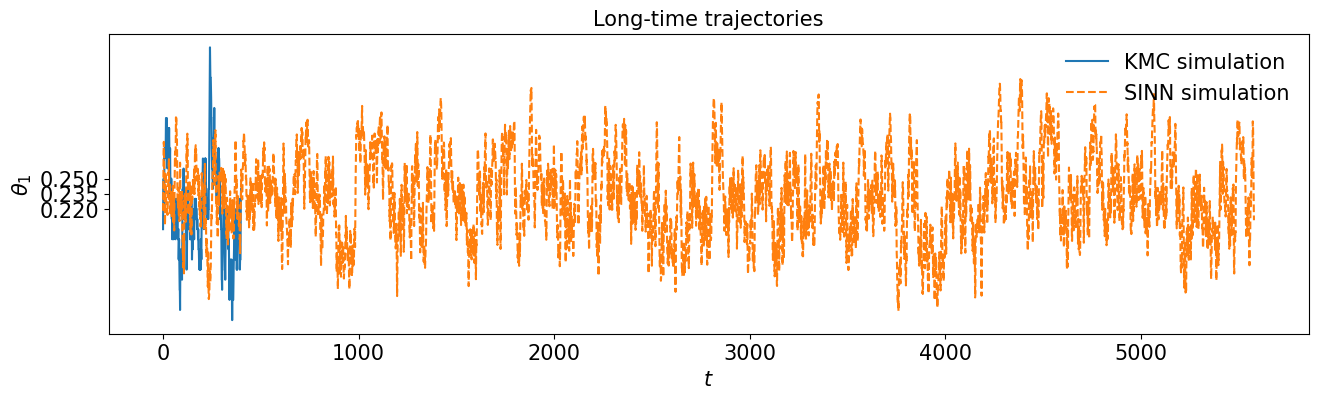

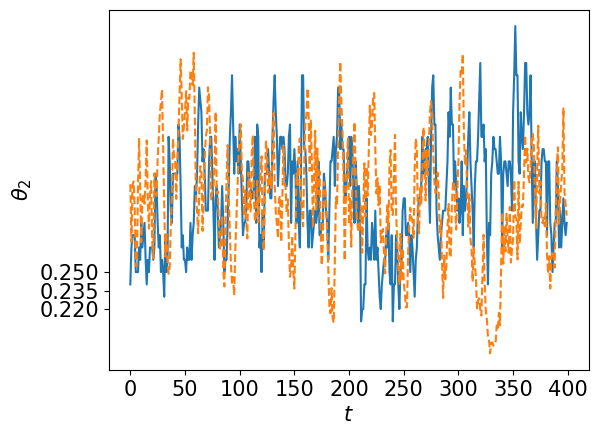

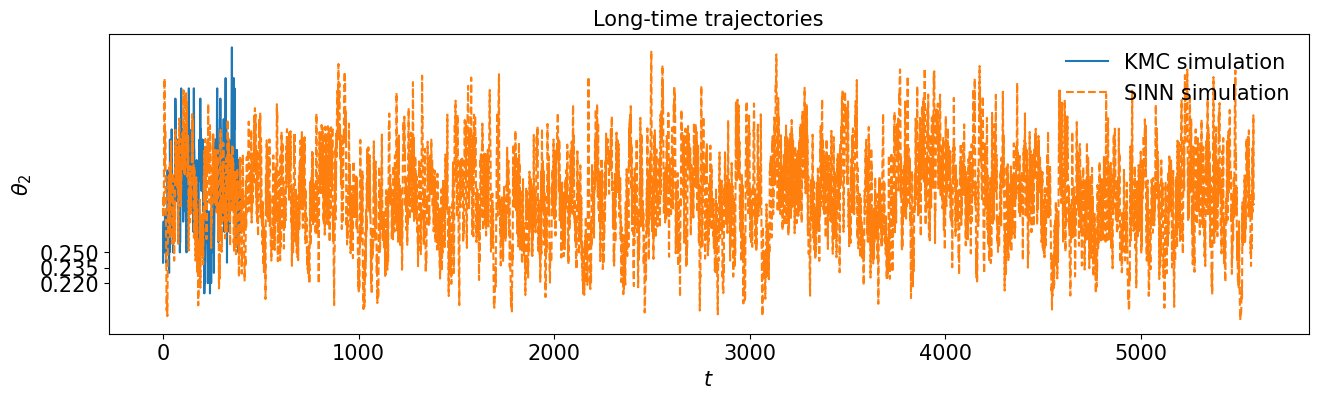

In [43]:
test5(AWmodel)

In [44]:
def test6(model):
    # Test 6: scatter plot of SINN
    ran_input=torch.randn(input.size(),dtype=input.dtype,layout=input.layout, device=input.device)
    Pred,_= model.predict_U(ran_input)
    prediction=Pred[-sec_length:,:,:].detach().cpu().numpy().reshape(sec_length, batch, 2)
    
    fig = plt.figure(0)
    plt.title("MD trajectories",fontsize=15) 
    plt.scatter(Traj[:,:,0], Traj[:,:,1])
    plt.xlabel(r'$\theta_1$',fontsize=15)
    plt.ylabel(r'$\theta_2$',fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15) 


    fig = plt.figure(1)
    plt.title("SINN trajectories",fontsize=15)    
    plt.scatter(prediction[:,:,0],prediction[:,:,1])
    plt.xlabel(r'$\theta_1$',fontsize=15)
    plt.ylabel(r'$\theta_2$',fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

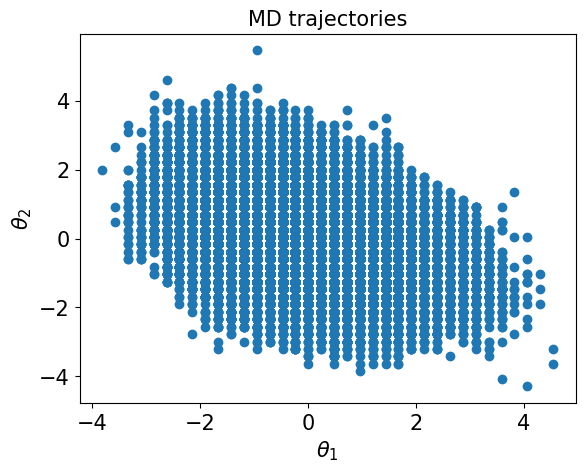

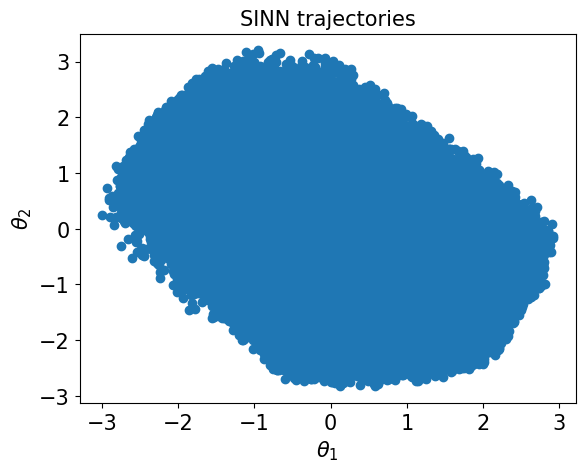

In [45]:
test6(AWmodel)

In [46]:
def test7(model):
    # Test 7: joint PDF of SINN
    ran_input=torch.randn(input.size(),dtype=input.dtype,layout=input.layout, device=input.device)
    Pred,_= model.predict_U(ran_input)
    prediction=Pred[-sec_length:,:,:].detach().cpu().numpy().reshape(sec_length, batch, 2)
    
    rho_data =  StatLoss.gauss_kde2D(target, -5, 5, 400, None).cpu()
    rho_prediction = StatLoss.gauss_kde2D(Pred[-sec_length:,:,:].detach(), -5, 5, 400, None).cpu()
    
    fig = plt.figure(0, figsize=(5, 5))
    plt.title("PDF Contours",fontsize=15) 
    xmin, xmax = -5, 5
    ymin, ymax = -5, 5

    xx, yy = np.mgrid[xmin:xmax:400j, ymin:ymax:400j]
    axs[0]  = fig.gca()
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    
    plt.contour(xx,yy,rho_data.numpy(),colors='r')
    plt.contour(xx,yy,rho_prediction.numpy(),colors='b',linestyles='dashed')

    plt.xlabel(r'$\theta_1$')
    plt.ylabel(r'$\theta_2$')

    
    
    fig = plt.figure(1,figsize=(5, 5))
    plt.title("MD trajectories",fontsize=15) 


    ax  = fig.gca()
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    cfset = ax.contourf(xx, yy, rho_data.numpy(), cmap='Blues')
    cset = ax.contour(xx, yy, rho_data.numpy(), colors='k')

    ax.clabel(cset, inline=1, fontsize=10)
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    
    fig = plt.figure(2,figsize=(5, 5))
    plt.title("SINN output",fontsize=15) 


#     xx, yy = np.mgrid[xmin:xmax:20j, ymin:ymax:20j]
    ax  = fig.gca()
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    cfset = ax.contourf(xx, yy, rho_prediction.numpy(), cmap='Blues')
    cset = ax.contour(xx, yy, rho_prediction.numpy(), colors='k')

    ax.clabel(cset, inline=1, fontsize=10)
    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')

    
    
    fig = plt.figure(3,figsize=(5, 5))
    ax = plt.figure().add_subplot(projection='3d')
# X, Y, Z = axes3d.get_test_data(0.05)

# Plot the 3D surface
    ax.plot_surface(xx, yy, rho_data.numpy(), edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

# Plot projections of the contours for each dimension.  By choosing offsets
# that match the appropriate axes limits, the projected contours will sit on
# the 'walls' of the graph.
    ax.contour(xx, yy, rho_data.numpy(), zdir='z', offset=-0.2, cmap='coolwarm')
    ax.contour(xx, yy, rho_data.numpy(), zdir='x', offset=-5, cmap='coolwarm')
    ax.contour(xx, yy, rho_data.numpy(), zdir='y', offset=5, cmap='coolwarm')

    ax.set(xlim=(-5, 5), ylim=(-5, 5), zlim=(-0.2, 0.4),xlabel=r'$\theta_1$', ylabel=r'$\theta_2$', zlabel=r'Prob($\theta_1$,$\theta_2$)')
    ax.set_box_aspect(aspect=None, zoom=0.8)

    
    

    

    
    
    
    fig = plt.figure(4,figsize=(5, 5))
    ax = plt.figure().add_subplot(projection='3d')
# X, Y, Z = axes3d.get_test_data(0.05)

# Plot the 3D surface
    ax.plot_surface(xx, yy, rho_prediction.numpy(), edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

# Plot projections of the contours for each dimension.  By choosing offsets
# that match the appropriate axes limits, the projected contours will sit on
# the 'walls' of the graph.
    ax.contour(xx, yy, rho_prediction.numpy(), zdir='z', offset=-0.2, cmap='coolwarm')
    ax.contour(xx, yy, rho_prediction.numpy(), zdir='x', offset=-5, cmap='coolwarm')
    ax.contour(xx, yy, rho_prediction.numpy(), zdir='y', offset=5, cmap='coolwarm')

    ax.set(xlim=(-5, 5), ylim=(-5, 5), zlim=(-0.2, 0.4),xlabel=r'$\theta_1$', ylabel=r'$\theta_2$', zlabel=r'Prob($\theta_1$,$\theta_2$)')
    ax.set_box_aspect(aspect=None, zoom=0.8)

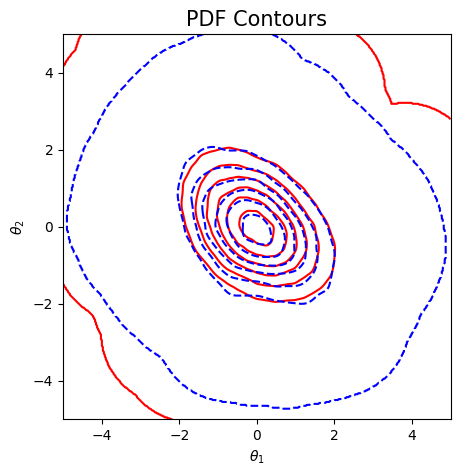

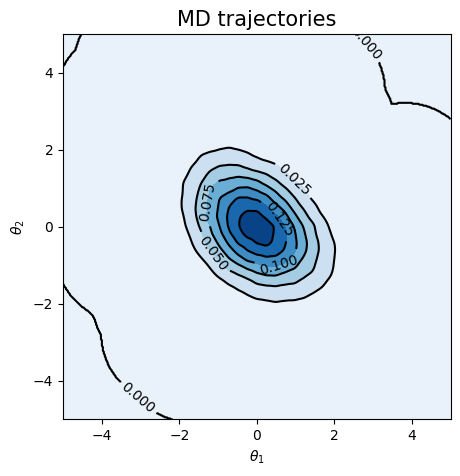

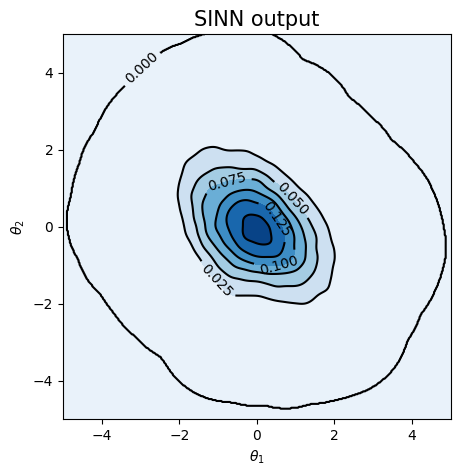

<Figure size 500x500 with 0 Axes>

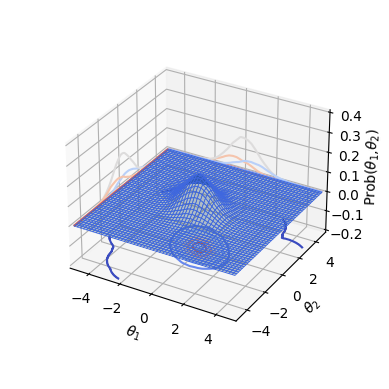

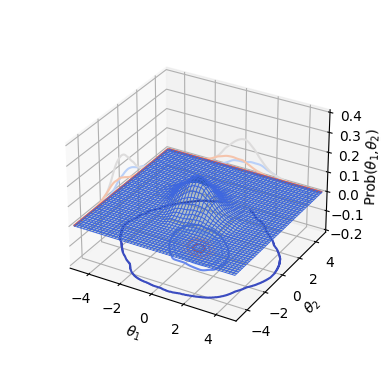

In [47]:
test7(AWmodel)

In [48]:
def test8(model):
    # Test 8: scatter plot of SINN
    ran_input=torch.randn(input.size(),dtype=input.dtype,layout=input.layout, device=input.device)
    Pred,_= model.predict_U(ran_input)
    prediction=Pred[-sec_length:,:,:].detach().cpu().numpy().reshape(sec_length, batch, 2)
    
    fig = plt.figure(0)
    plt.title("MD trajectories",fontsize=15) 
    plt.scatter(traj_theta1[:,:], traj_theta2[:,:])
    plt.xlabel(r'$\theta_1$',fontsize=15)
    plt.ylabel(r'$\theta_2$',fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15) 


    fig = plt.figure(1)
    plt.title("SINN trajectories",fontsize=15)    
    plt.scatter(prediction[:,:,0]*std1+mean1,prediction[:,:,1]*std2+mean2)
    plt.xlabel(r'$\theta_1$',fontsize=15)
    plt.ylabel(r'$\theta_2$',fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

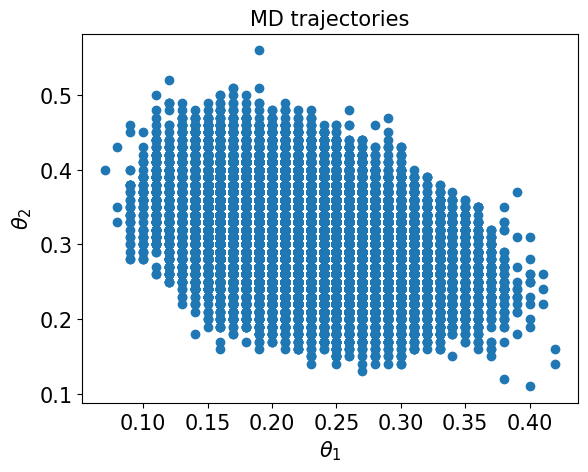

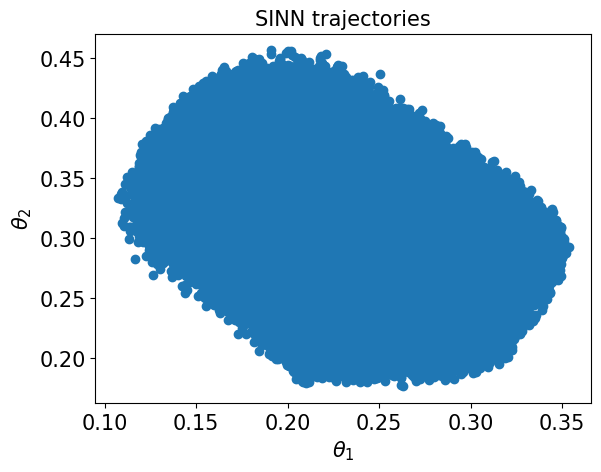

In [49]:
test8(AWmodel)

In [50]:
def scatter_hist(x, y, ax, ax_histx, ax_histy):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    # the scatter plot:
    ax.scatter(x, y, s=0.05)

    # now determine nice limits by hand:
    binwidth = 0.25*(std1+std2)
#     binwidth = 0.25*(std1+std2)/2

    xymax = max(np.max(x), np.max(y))
    xymin = min(np.min(x), np.min(y))
    
    # Ensure limits encompass the range of data
    lim_min = (int(xymin / binwidth) - 1) * binwidth  # Set minimum limit
    lim_max = (int(xymax / binwidth) + 1) * binwidth  # Set maximum limit

    # Create bins from lim_min to lim_max
    bins = np.arange(lim_min, lim_max + binwidth, binwidth)    
    
    ax_histx.hist(x, bins=bins, density=True, alpha=0.6)
    ax_histy.hist(y, bins=bins, density=True, alpha=0.6, orientation='horizontal')
    
    # Calculate KDE for x and y
    kde_x = gaussian_kde(x)
    kde_y = gaussian_kde(y)

    # Generate smooth values for the KDE curve
    x_vals = np.linspace(lim_min, lim_max, 400)
    y_vals = np.linspace(lim_min, lim_max, 400)

    # Plot KDE curves on the histograms
    ax_histx.plot(x_vals, kde_x(x_vals), color='red')
    ax_histy.plot(kde_y(y_vals), y_vals, color='red')
    
    # 2D KDE Calculation
    xy = np.vstack([x, y])
    kde_2d = gaussian_kde(xy)
    
    # Create a grid of x and y values
    xgrid, ygrid = np.meshgrid(np.linspace(lim_min, lim_max, 400), 
                               np.linspace(lim_min, lim_max, 400))
    grid_coords = np.vstack([xgrid.ravel(), ygrid.ravel()])
    
    # Evaluate KDE on the grid
    z = kde_2d(grid_coords).reshape(xgrid.shape)
#     levels = [0.15, 0.275, 0.375, 0.45, 0.5, 0.525]
    
    # Plot 2D KDE as a contour plot
    contours = ax.contourf(xgrid, ygrid, z, cmap='Blues', alpha=0.5)  # KDE Contours
    
    # Optionally add contour lines
    contour_lines = ax.contour(xgrid, ygrid, z, colors='black')
    
    # Add contour labels if desired
    ax.clabel(contour_lines, inline=1)
    
#     ax.set_xlim(0.11, 0.35)
#     ax.set_ylim(0.17, 0.45)

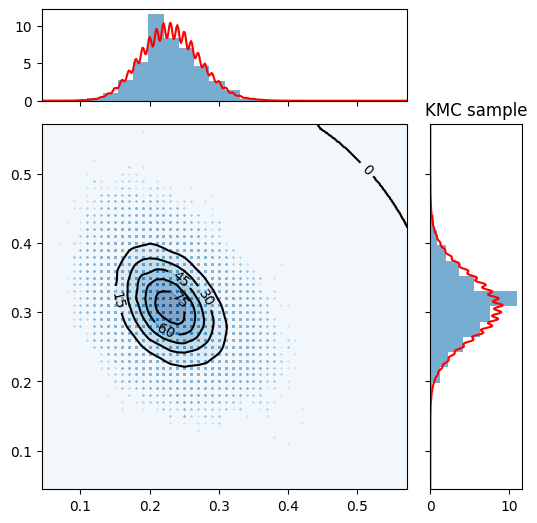

In [51]:
# Assuming Traj is a 3D numpy array
# Reshape x and y to 1D arrays if they are not already.
x = (traj_theta1[:,:]).ravel()
y = (traj_theta2[:,:]).ravel()

# Start with a square Figure.
fig = plt.figure(figsize=(6, 6))

# Add a gridspec with two rows and two columns
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.1, hspace=0.1)

# Create the Axes for scatter plot and marginal histograms.
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

# Draw the scatter plot and marginals using the scatter_hist function.
scatter_hist(x, y, ax, ax_histx, ax_histy)
plt.title('KMC sample')
# Display plot
plt.show()

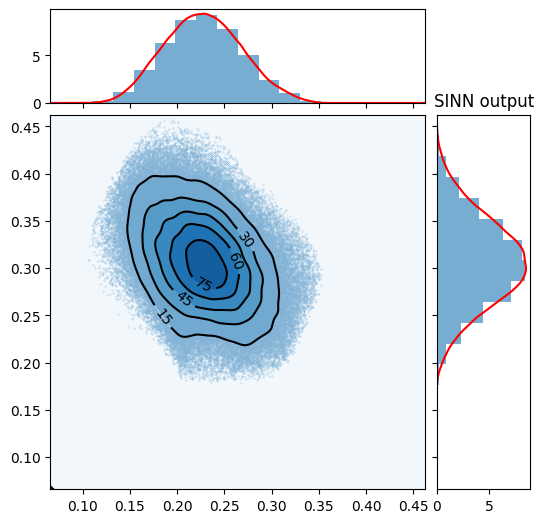

In [52]:
ran_input=torch.randn(input.size(),dtype=input.dtype,layout=input.layout, device=input.device)
Pred,_= AWmodel.predict_U(ran_input)
prediction=Pred[-sec_length:,:,:].detach().cpu().numpy().reshape(sec_length, batch, 2)

x = (prediction[:,:,0]*std1+mean1).ravel()
y = (prediction[:,:,1]*std2+mean2).ravel()

# Start with a square Figure.
fig = plt.figure(figsize=(6, 6))

# Add a gridspec with two rows and two columns
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)

# Create the Axes for scatter plot and marginal histograms.
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

# Draw the scatter plot and marginals using the scatter_hist function.
scatter_hist(x, y, ax, ax_histx, ax_histy)
plt.title('SINN output')
# Display plot
plt.show()